<a href="https://colab.research.google.com/github/anmol344-jpg/AI-STUDENT-DATA-UNTELLIGENCE/blob/main/Gait_Eye_V1_prototype.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Phase- 1
- For Drive mount
- Drive link - [Gait model](https://drive.google.com/drive/folders/1ZQ8qRxKKBl92EN2znmdDYqJfl4lD12Ca?usp=sharing)
- Check out the following list of files 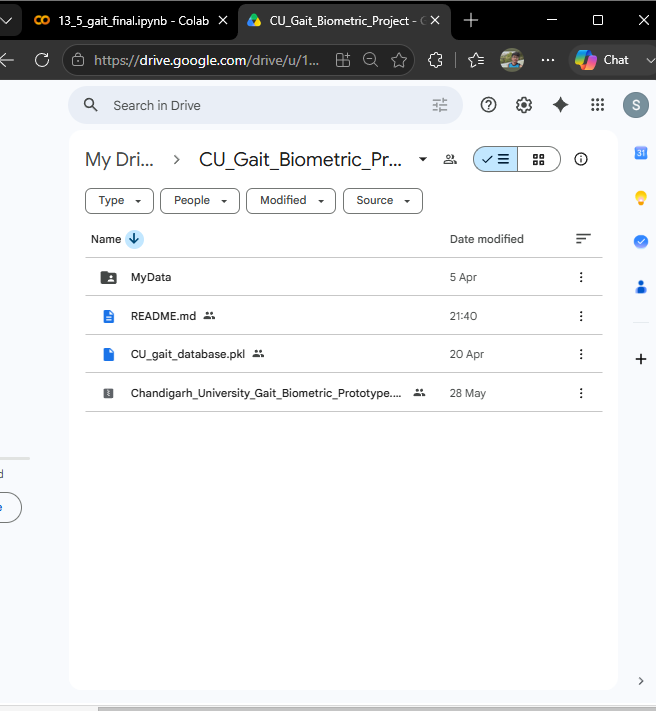
- Download the drive floder into your drive a/c.
- Then run this phase 1

In [1]:
# ==========================================================
#  Anmol run this phase-1
# ==========================================================
import os
import shutil
import cv2
import numpy as np
import pickle
import warnings
warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

from tensorflow.keras.models import load_model
from tensorflow.keras import models
from google.colab import drive

print("⏳ [1/5] Connecting to Secure Google Drive...")
drive.mount('/content/drive', force_remount=True)

# --- 📁 DIRECTORY MANAGEMENT & MIGRATION ---
base_dir = "/content/drive/MyDrive/CU_Gait_Biometric_Project"
os.makedirs(base_dir, exist_ok=True)
print(f"📁 [2/5] Project Directory Verified: {base_dir}")

old_model_path = "/content/drive/MyDrive/Chandigarh_University_Gait_Biometric_Prototype.keras"
new_model_path = os.path.join(base_dir, "Chandigarh_University_Gait_Biometric_Prototype.keras")

old_db_path = "/content/drive/MyDrive/CU_gait_database.pkl"
new_db_path = os.path.join(base_dir, "CU_gait_database.pkl")

# Move files if they are in the old location
if os.path.exists(old_model_path) and not os.path.exists(new_model_path):
    print("   -> Moving AI Model to new Project Folder...")
    shutil.move(old_model_path, new_model_path)

if os.path.exists(old_db_path) and not os.path.exists(new_db_path):
    print("   -> Moving Database to new Project Folder...")
    shutil.move(old_db_path, new_db_path)

# ---  GENERATE DEVELOPER README ---
readme_path = os.path.join(base_dir, "README.md")
readme_content = """# Chandigarh University Gait Biometric Project
##  Project Overview
This repository contains the core deep learning assets and database for the CU Gait Biometric Authentication System.

##  The AI Pipeline (For Future Web/Mobile Developers)
To integrate this model into an iOS/Android app or a React/Next.js frontend, follow this architecture:
1. **Video Capture:** The mobile app captures a 3-5 second walking video (MP4/MOV).
2. **Chunked Transmission:** Due to mobile payload limits, the video must be uploaded via Base64 in 1MB chunks to the Python backend (FastAPI/Flask).
3. **Silhouette Extraction:** OpenCV uses `createBackgroundSubtractorMOG2` to separate the human from the background.
4. **GEI Generation:** The silhouettes are averaged into a single image called a Gait Energy Image (GEI).
5. **Feature Extraction:** The `.keras` deep learning model extracts a high-dimensional biometric signature from the GEI.
6. **Matching:** Cosine Similarity is calculated against the `CU_gait_database.pkl`. A score > 80% grants access.

##  File Structure
* `Chandigarh_University_Gait_Biometric_Prototype.keras` -> The trained Neural Network.
* `CU_gait_database.pkl` -> The encrypted dictionary storing registered user signatures.
* `README.md` -> Developer integration instructions.
"""
with open(readme_path, "w") as f:
    f.write(readme_content)

# ---  LOAD AI MODEL ---
print("⏳ [3/5] Loading CU Enterprise AI Model...")
if not os.path.exists(new_model_path):
    print(f"❌ CRITICAL ERROR: Model not found at {new_model_path}!")
else:
    base_model = load_model(new_model_path)
    feature_model = models.Model(
        inputs=base_model.inputs,
        outputs=base_model.get_layer('biometric_feature_layer').output
    )
    print("✅ Model Loaded Successfully!")

# ---  LOAD DATABASE ---
print("⏳ [4/5] Synchronizing Cloud Database...")
try:
    with open(new_db_path, "rb") as f:
        database = pickle.load(f)
    db_status = f"DATABASE ONLINE: {len(database)} Subjects Enrolled."
    status_color = "#27ae60"
except:
    database = {}
    db_status = "SYSTEM INITIALIZED: Empty Database."
    status_color = "#e67e22"
print(f"✅ {db_status}")

# ---  COMPILE CORE FUNCTIONS ---
print("⏳ [5/5] Compiling Core AI Functions...")
def video_to_gei_deep(video_path, num_frames=60):
    cap = cv2.VideoCapture(video_path)
    fgbg = cv2.createBackgroundSubtractorMOG2(history=500, varThreshold=25, detectShadows=False)
    silhouettes = []
    frame_count = 0
    while True:
        ret, frame = cap.read()
        if not ret or frame_count >= num_frames: break
        fgmask = fgbg.apply(frame)
        kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
        fgmask = cv2.morphologyEx(fgmask, cv2.MORPH_OPEN, kernel)
        contours, _ = cv2.findContours(fgmask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if contours:
            largest = max(contours, key=cv2.contourArea)
            if cv2.contourArea(largest) > 800:
                x, y, w, h = cv2.boundingRect(largest)
                if (h / float(w)) > 1.2:
                    human = cv2.resize(fgmask[y:y+h, x:x+w], (128, 128))
                    silhouettes.append(human)
        frame_count += 1
    cap.release()
    if len(silhouettes) < 10: return "NOT_GAIT"
    gei = np.mean(silhouettes, axis=0) / 255.0
    gei_3ch = np.repeat(gei[:, :, np.newaxis], 3, axis=-1)
    return gei_3ch.reshape(1, 128, 128, 3)

def extract_deep_features(video_path):
    gei = video_to_gei_deep(video_path)
    if isinstance(gei, str) and gei == "NOT_GAIT": return "NOT_GAIT"
    if gei is None: return None
    return feature_model.predict(gei, verbose=0)

print("\n PHASE 1 COMPLETE! The AI Brain is awake, files are organized, and ready for UI Launch.")

⏳ [1/5] Connecting to Secure Google Drive...
Mounted at /content/drive
📁 [2/5] Project Directory Verified: /content/drive/MyDrive/CU_Gait_Biometric_Project
⏳ [3/5] Loading CU Enterprise AI Model...
✅ Model Loaded Successfully!
⏳ [4/5] Synchronizing Cloud Database...
✅ DATABASE ONLINE: 3 Subjects Enrolled.
⏳ [5/5] Compiling Core AI Functions...

 PHASE 1 COMPLETE! The AI Brain is awake, files are organized, and ready for UI Launch.


## Phase - 2
- Connet the model with the web page
### For Save new student
- Write the name
- Upload the video and click on **Enroll Subjets**
- Sync to Secure cloud
### For Check
- Upload vedio
- click on **Authenticate**

In [2]:
import IPython
from IPython.display import display, HTML, JSON
from google.colab import output
import base64
import numpy as np
import pickle
import os

#  SAFETY CHECK
if 'feature_model' not in globals() or 'database' not in globals():
    print("⚠️ 🛑 SYSTEM OFFLINE: Google Colab's memory was erased! 🛑")
    print("👉 Please scroll up and run PHASE 1 to wake up the AI first.")
else:
    #  BACKEND PROCESSORS
    def receive_chunk(b64_chunk, filename, chunk_index, total_chunks):
        try:
            path = f"/content/{filename}"
            mode = "wb" if int(chunk_index) == 0 else "ab"
            if ',' in b64_chunk: b64_chunk = b64_chunk.split(',')[1]
            video_bytes = base64.b64decode(b64_chunk)
            with open(path, mode) as f: f.write(video_bytes)
            return JSON({"status": "ok"})
        except Exception as e:
            return JSON({"status": "error", "message": str(e)})

    def process_video_backend(action, subject_name, filename):
        try:
            path = f"/content/{filename}"
            feat = extract_deep_features(path)
            if os.path.exists(path): os.remove(path)

            if isinstance(feat, str): return JSON({"status": "error", "message": "SECURITY REJECT: Subject is not walking. Facial/Static media denied."})
            if feat is None: return JSON({"status": "error", "message": "Failed to read video file format."})

            if action == "register":
                if subject_name not in database: database[subject_name] = []
                database[subject_name].append(feat)
                return JSON({"status": "success", "message": f"Successfully Enrolled '{subject_name}'. (Total Profiles: {len(database[subject_name])})"})

            elif action == "recognize":
                if not database: return JSON({"status": "error", "message": "Database is empty. Please Enroll someone first."})
                best_match, best_sim = None, -1.0
                for db_name, saved_feats in database.items():
                    for s_feat in saved_feats:
                        sim = np.dot(feat.flatten(), s_feat.flatten()) / (np.linalg.norm(feat) * np.linalg.norm(s_feat))
                        if sim > best_sim: best_sim = sim; best_match = db_name

                conf = max(0, min(100, best_sim * 100))
                if conf >= 80.0: return JSON({"status": "success", "match": best_match, "confidence": round(float(conf), 2)})
                else: return JSON({"status": "error", "message": f"ACCESS DENIED: Unknown Biometric Signature. (Confidence: {round(float(conf), 2)}%)"})
        except Exception as e: return JSON({"status": "error", "message": f"Python AI Crash: {str(e)}"})

    def save_database_backend():
        try:
            with open(new_db_path, "wb") as f: pickle.dump(database, f)
            return JSON({"status": "success", "message": f"Successfully synced {len(database)} identities to Google Drive Folder."})
        except Exception as e: return JSON({"status": "error", "message": f"Sync Failed: {str(e)}"})

    output.register_callback('receive_chunk', receive_chunk)
    output.register_callback('process_video_backend', process_video_backend)
    output.register_callback('save_database_backend', save_database_backend)

    #  PROFESSIONAL HTML/CSS
    html_code = f"""
    <!DOCTYPE html>
    <html>
    <head>
        <style>
            body {{ font-family: 'Segoe UI', Roboto, Helvetica, Arial, sans-serif; background-color: #f0f2f5; padding: 20px; }}
            .container {{ background-color: white; padding: 35px; border-radius: 12px; box-shadow: 0 8px 30px rgba(0,0,0,0.08); max-width: 600px; margin: 0 auto; border-top: 8px solid #E21A22; }}
            .header {{ display: flex; align-items: center; margin-bottom: 25px; border-bottom: 2px solid #f1f3f5; padding-bottom: 20px; }}
            .logo-box {{ background-color: #E21A22; color: white; padding: 15px 18px; border-radius: 8px; font-size: 26px; font-weight: 800; margin-right: 18px; letter-spacing: 1px; }}
            .title {{ color: #1e272e; margin: 0; font-size: 22px; font-weight: 700; }}
            .subtitle {{ color: #E21A22; margin: 4px 0 0 0; font-size: 14px; font-weight: 500; }}

            label {{ font-weight: 600; color: #4a4a4a; display: block; margin-top: 18px; font-size: 14px; }}
            input[type="text"], input[type="file"] {{ width: 100%; padding: 14px; margin-top: 8px; border: 2px solid #dfe4ea; border-radius: 8px; box-sizing: border-box; font-size: 15px; color: #2f3542; transition: all 0.3s; background-color: #f8f9fa; }}
            input[type="text"]:focus {{ border-color: #E21A22; outline: none; background-color: #ffffff; box-shadow: 0 0 0 3px rgba(226, 26, 34, 0.1); }}

            .actions {{ display: flex; justify-content: space-between; margin-top: 25px; flex-wrap: wrap; gap: 12px; }}
            .btn {{ padding: 15px; border: none; border-radius: 8px; cursor: pointer; color: white; font-weight: 600; width: 48%; font-size: 15px; transition: transform 0.1s, opacity 0.3s; box-shadow: 0 4px 6px rgba(0,0,0,0.1); }}
            .btn:active {{ transform: scale(0.98); }}
            .btn-register {{ background-color: #27ae60; }}
            .btn-recognize {{ background-color: #2980b9; }}
            .btn-save {{ background-color: #f39c12; width: 100%; margin-top: 5px; }}
            .btn:disabled {{ background-color: #a4b0be; cursor: not-allowed; box-shadow: none; transform: none; }}

            .progress-wrapper {{ display: none; margin-top: 20px; text-align: center; }}
            .progress-background {{ width: 100%; background-color: #ecf0f1; border-radius: 10px; overflow: hidden; height: 20px; border: 1px solid #ced6e0; }}
            .progress-bar {{ height: 100%; width: 0%; background-color: #27ae60; border-radius: 10px; transition: width 0.2s ease-out; }}
            .progress-text {{ margin-top: 10px; font-weight: 600; color: #576574; font-size: 13px; }}

            /*  FIXED: High Contrast Output Box */
            #outputBox {{ margin-top: 25px; padding: 18px; border-radius: 8px; background-color: #f1f2f6; color: #2f3542; text-align: center; font-weight: 600; min-height: 24px; border: 1px solid #dfe4ea; font-size: 15px; line-height: 1.5; }}
        </style>
    </head>
    <body>

    <div class="container">
        <div class="header">
            <div class="logo-box">CU</div>
            <div>
                <h2 class="title">CHANDIGARH UNIVERSITY</h2>
                <p class="subtitle">Enterprise Gait Biometric System</p>
                <p style="color: {status_color}; margin: 6px 0 0 0; font-weight: 700; font-size: 12px; display: flex; align-items: center;">🟢 {db_status}</p>
            </div>
        </div>

        <!--  CUSTOM SAYON PLACEHOLDER -->
        <label>Subject ID (Registration only):</label>
        <input type="text" id="subjectName" placeholder="Enter Subject Name (e.g. Sayon)">

        <label>Secure Media Upload:</label>
        <input type="file" id="videoFile" accept="video/mp4, video/avi, video/mov">

        <div class="progress-wrapper" id="progressWrapper">
            <div class="progress-background">
                <div class="progress-bar" id="progressBar"></div>
            </div>
            <div class="progress-text" id="progressText">Transmitting Payload: 0%</div>
        </div>

        <div class="actions">
            <button class="btn btn-register" id="btnReg" onclick="startProcess('register')">🔐 Enroll Subject</button>
            <button class="btn btn-recognize" id="btnRec" onclick="startProcess('recognize')">👁️ Authenticate</button>
            <button class="btn btn-save" id="btnSave" onclick="saveDatabase()">💾 Sync to Secure Cloud</button>
        </div>

        <div id="outputBox">🟢 System Ready. Awaiting Video Input.</div>
    </div>

    <script>
        function extractPythonData(rawResponse) {{
            if (rawResponse.data && rawResponse.data['application/json']) return rawResponse.data['application/json'];
            throw new Error("Invalid response format.");
        }}

        function setOutput(bgColor, textColor, htmlContent) {{
            const box = document.getElementById('outputBox');
            box.style.backgroundColor = bgColor;
            box.style.color = textColor;
            box.style.borderColor = textColor;
            box.innerHTML = htmlContent;
        }}

        async function saveDatabase() {{
            setOutput("#fff3cd", "#856404", "⏳ Syncing records to Google Drive...");
            try {{
                const resultRaw = await google.colab.kernel.invokeFunction('save_database_backend', [], {{}});
                const result = extractPythonData(resultRaw);
                if(result.status === "success") setOutput("#d4edda", "#155724", `✅ ${{result.message}}`);
                else setOutput("#f8d7da", "#721c24", `🚨 ${{result.message}}`);
            }} catch (error) {{
                setOutput("#f8d7da", "#721c24", `❌ Sync Error: ${{error.message}}`);
            }}
        }}

        async function startProcess(action) {{
            const fileInput = document.getElementById('videoFile');
            const nameInput = document.getElementById('subjectName').value.trim();
            const progressWrapper = document.getElementById('progressWrapper');
            const progressBar = document.getElementById('progressBar');
            const progressText = document.getElementById('progressText');

            const btnReg = document.getElementById('btnReg');
            const btnRec = document.getElementById('btnRec');
            const btnSave = document.getElementById('btnSave');

            if (fileInput.files.length === 0) return setOutput("#fff3cd", "#856404", "⚠️ Please select a video file first.");
            if (action === 'register' && nameInput === "") return setOutput("#fff3cd", "#856404", "⚠️ Please enter a name to register (e.g. Sayon).");

            const file = fileInput.files[0];

            btnReg.disabled = true; btnRec.disabled = true; btnSave.disabled = true; fileInput.disabled = true;
            progressWrapper.style.display = "block";
            progressBar.style.width = "0%";
            progressBar.style.backgroundColor = "#27ae60";

            setOutput("#e2e3e5", "#383d41", "⏳ Initializing secure chunked transmission...");

            const chunkSize = 1024 * 1024;
            const totalChunks = Math.ceil(file.size / chunkSize);
            let currentChunk = 0;

            async function uploadNextChunk() {{
                const start = currentChunk * chunkSize;
                const end = Math.min(start + chunkSize, file.size);
                const blob = file.slice(start, end);

                const reader = new FileReader();
                reader.onload = async function(e) {{
                    const b64 = e.target.result;
                    try {{
                        await google.colab.kernel.invokeFunction('receive_chunk', [b64, file.name, currentChunk, totalChunks], {{}});
                        currentChunk++;
                        let percent = Math.round((currentChunk / totalChunks) * 100);
                        progressBar.style.width = percent + "%";
                        progressText.innerText = "Transmitting Payload: " + percent + "%";

                        if (currentChunk < totalChunks) {{
                            uploadNextChunk();
                        }} else {{
                            progressBar.style.backgroundColor = "#f39c12";
                            progressText.innerText = "✅ Transmission Complete! Extracting Biometrics...";
                            setOutput("#cce5ff", "#004085", "🧠 AI Neural Network is analyzing gait geometry...");

                            try {{
                                const resultRaw = await google.colab.kernel.invokeFunction('process_video_backend', [action, nameInput, file.name], {{}});
                                const result = extractPythonData(resultRaw);

                                if (result.status === "success") {{
                                    if (action === 'recognize') {{
                                        setOutput("#d4edda", "#155724", `✅ <b style="font-size: 18px;">ACCESS GRANTED</b><br><br>👤 IDENTIFIED: <span style="font-size:22px; font-weight:800;">${{result.match}}</span><br>Match Confidence: ${{result.confidence}}%`);
                                    }} else {{
                                        setOutput("#d4edda", "#155724", `✅ ${{result.message}}`);
                                    }}
                                }} else {{
                                    setOutput("#f8d7da", "#721c24", `🚨 ${{result.message}}`);
                                }}
                            }} catch (error) {{
                                setOutput("#f8d7da", "#721c24", `❌ Processing Error: ${{error.message}}`);
                            }}

                            btnReg.disabled = false; btnRec.disabled = false; btnSave.disabled = false; fileInput.disabled = false;
                            progressWrapper.style.display = "none";
                            fileInput.value = "";
                        }}
                    }} catch (error) {{
                        setOutput("#f8d7da", "#721c24", `❌ Upload Interrupted: ${{error.message}}`);
                        btnReg.disabled = false; btnRec.disabled = false; btnSave.disabled = false; fileInput.disabled = false;
                    }}
                }};
                reader.readAsDataURL(blob);
            }}

            uploadNextChunk();
        }}
    </script>
    </body>
    </html>
    """
    display(HTML(html_code))

## Future Research
- 1.Stroke

A stroke can weaken or partially paralyze one side of the body.

Why gait changes:

One leg may not bend normally.
Muscle control and strength become unequal.

Observable signs:

Circumduction gait: the weak leg swings outward in a semicircle.
Strong left-right asymmetry: one side moves differently from the other.
Pelvic tilt: uneven hip movement.
Unequal step length and timing.

A person with left-side weakness may swing the left leg outward because lifting it normally is difficult.
- 2.Diabetes (Diabetic Neuropathy)

Diabetic neuropathy is nerve damage that can occur in people with diabetes, especially in the feet and legs.

Diabetic Neuropathy

Why gait changes:

The person may have reduced sensation in their feet.
Balance becomes more difficult.
They may not clearly feel where their feet are on the ground.

Observable signs:

Wider step width: feet placed farther apart for stability.
Reduced foot clearance: toes come closer to the ground while walking.
Steppage gait: knees lifted unusually high to prevent the toes from dragging.
More frequent stumbling or balance corrections.
- 3.Osteoarthritis

Osteoarthritis causes cartilage in joints to wear down, leading to pain and stiffness.

Why gait changes:

Moving the affected joint hurts.
The body automatically tries to reduce stress on the painful side.

Observable signs:

Reduced knee/hip movement: joints bend less during walking.
Shorter stride length: steps become smaller.
Body lean: the person leans away from the painful joint to reduce load.
Walking speed often decreases.

For example, if the right hip hurts, the person may spend less time standing on the right leg and take shorter steps.
- 4.Parkinson's Disease

Parkinson's affects movement control in the brain.

Why gait changes:

Muscles become rigid.
Movements become slower.
Automatic motions become reduced.

Observable signs:

Shuffling gait: very small steps.
Low foot lift: feet stay close to the ground.
Reduced arm swing: one or both arms move less while walking.
Forward-leaning posture.
Gait freezing: the person briefly feels "stuck" and cannot initiate movement.

These features are among the most studied gait markers for Parkinson's.